# <u>Muhammad Owais Ur Rehaman Assignment</u>

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Creating a dataset

In [118]:
# Creating dataset of 500 employees with the following attributes
data={
    'ID':np.random.randint(1,500,size=500),
    'Name':np.random.choice(['John','Jane','Mike','Sarah','David','Ali','Ahmed','Abbas','Alam'],size=500),
    'Age':np.random.randint(22,60,size=500),
    'Gender':np.random.choice(['Male','Female'],size=500),
    'Salary':np.random.randint(4000,12000,size=500),
    'year_at_company':np.random.randint(1,30,size=500),
    'performance':np.random.randint(1,5,size=500)
}

In [119]:
df=pd.DataFrame(data)
df.head()

,ID,Name,Age,Gender,Salary,year_at_company,performance
0,22,Ahmed,43,Female,9675,10,2
1,223,Ali,51,Male,7773,23,1
2,196,David,25,Female,5795,2,3
3,337,David,33,Male,8396,9,1
4,321,David,37,Male,6123,27,1


In [120]:
df['promotion_eligibility']=np.where(df['performance']>3,'Yes','No')
df.head()

,ID,Name,Age,Gender,Salary,year_at_company,performance,promotion_eligibility
0,22,Ahmed,43,Female,9675,10,2,No
1,223,Ali,51,Male,7773,23,1,No
2,196,David,25,Female,5795,2,3,No
3,337,David,33,Male,8396,9,1,No
4,321,David,37,Male,6123,27,1,No


In [121]:
df.rename(columns={'year_at_company':'S_Duration','promotion_eligibility':'eligibility'},inplace=True)
df

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,22,Ahmed,43,Female,9675,10,2,No
1,223,Ali,51,Male,7773,23,1,No
2,196,David,25,Female,5795,2,3,No
3,337,David,33,Male,8396,9,1,No
4,321,David,37,Male,6123,27,1,No
...,...,...,...,...,...,...,...,...
495,366,John,44,Female,7988,18,2,No
496,318,Mike,36,Female,4781,5,1,No
497,182,Sarah,55,Male,8205,10,4,Yes
498,82,Ahmed,26,Male,5704,16,2,No


#<span style="color:cyan"><u> Set 10% salary values to missing NaN </u></span>

In [122]:
np.random.seed(0)
get_nan=np.random.rand(len(df))<0.1
df.loc[get_nan,'Salary']=np.nan
df.head(10)

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,22,Ahmed,43,Female,9675.0,10,2,No
1,223,Ali,51,Male,7773.0,23,1,No
2,196,David,25,Female,5795.0,2,3,No
3,337,David,33,Male,8396.0,9,1,No
4,321,David,37,Male,6123.0,27,1,No
5,130,Abbas,48,Female,10449.0,8,4,Yes
6,307,Mike,37,Male,5074.0,13,2,No
7,353,Mike,55,Female,11306.0,10,4,Yes
8,364,Ahmed,33,Female,5195.0,18,4,Yes
9,467,Ali,27,Female,8815.0,18,2,No


#<span style="color:orange"><u> To check which columns contains the NaN values </u></span>

In [123]:
df.isnull().sum()

ID              0
Name            0
Age             0
Gender          0
Salary         50
S_Duration      0
performance     0
eligibility     0
dtype: int64

#<span style="color:green"><u> Select only that column that have missing NaN </u></span>

In [124]:
columns_with_nan=df.columns[df.isna().any()].tolist()
columns_with_nan

['Salary']

In [125]:
ser=df.isna().any()
ser # This code tells us that is there any column with missing NaN


ID             False
Name           False
Age            False
Gender         False
Salary          True
S_Duration     False
performance    False
eligibility    False
dtype: bool

In [126]:
ser1=df.isna()
ser1.head() # This code tells us that is there any dataframe cell with missing NaN

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


## Replace the performance 5% values with invalid (-1,6)

In [127]:
np.random.seed(0)
randno=int(len(df)*0.05)
replace_indexes=df['performance'].sample(n=randno).index
df.loc[replace_indexes,'performance']=np.random.choice([-1,6],size=randno)
df.head()

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,22,Ahmed,43,Female,9675.0,10,2,No
1,223,Ali,51,Male,7773.0,23,1,No
2,196,David,25,Female,5795.0,2,3,No
3,337,David,33,Male,8396.0,9,1,No
4,321,David,37,Male,6123.0,27,1,No


In [128]:
# np.random.seed(0)
# res=df['performance'].sample(n=10,random_state=0)
# res

In [129]:
# res1=df['performance'].sample(n=10,random_state=0).index
# res1

# Fill the salary with the Mean

In [130]:
mean_sal=df['Salary'].mean()
df['Salary'].fillna(mean_sal,inplace=True)
df.head(50)

C:\Users\pak\AppData\Local\Temp\ipykernel_13456\2311846960.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(mean_sal,inplace=True)


,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,22,Ahmed,43,Female,9675.000000,10,2,No
1,223,Ali,51,Male,7773.000000,23,1,No
2,196,David,25,Female,5795.000000,2,3,No
3,337,David,33,Male,8396.000000,9,1,No
4,321,David,37,Male,6123.000000,27,1,No
5,130,Abbas,48,Female,10449.000000,8,4,Yes
6,307,Mike,37,Male,5074.000000,13,2,No
7,353,Mike,55,Female,11306.000000,10,4,Yes
8,364,Ahmed,33,Female,5195.000000,18,4,Yes
9,467,Ali,27,Female,8815.000000,18,2,No


In [131]:
df['Salary']=df['Salary'].round(2)
df
# This code will restrict the salary to only one decimal number

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,22,Ahmed,43,Female,9675.0,10,2,No
1,223,Ali,51,Male,7773.0,23,1,No
2,196,David,25,Female,5795.0,2,3,No
3,337,David,33,Male,8396.0,9,1,No
4,321,David,37,Male,6123.0,27,1,No
...,...,...,...,...,...,...,...,...
495,366,John,44,Female,7988.0,18,2,No
496,318,Mike,36,Female,4781.0,5,1,No
497,182,Sarah,55,Male,8205.0,10,4,Yes
498,82,Ahmed,26,Male,5704.0,16,2,No


## Filter out the Employee's with invalid scores

In [132]:
invalid_score_employee=df.loc[(df['performance']<0)|(df['performance']>5),('Name','ID','Gender')]
invalid_score_employee.head()

,Name,ID,Gender
15,Alam,29,Male
37,David,460,Male
45,Mike,194,Female
90,Sarah,286,Male
108,Abbas,22,Male


In [133]:
invalid_score_employee['Gender']=invalid_score_employee['Gender'].replace({'Male':1,'Female':0})
invalid_score_employee.head(15)

C:\Users\pak\AppData\Local\Temp\ipykernel_13456\1458305922.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  invalid_score_employee['Gender']=invalid_score_employee['Gender'].replace({'Male':1,'Female':0})


,Name,ID,Gender
15,Alam,29,1
37,David,460,1
45,Mike,194,0
90,Sarah,286,1
108,Abbas,22,1
153,David,112,1
154,David,145,0
159,Ahmed,8,0
171,Alam,206,1
205,Mike,125,0


## Department_Wise Salary analysis

In [134]:
df['Department']=np.random.choice(['Education','FIA','FBR','IB','Police','Judge','Medical','Senate','Ministry'
                                  ,'IT'],size=500)
df.head()

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility,Department
0,22,Ahmed,43,Female,9675.0,10,2,No,FIA
1,223,Ali,51,Male,7773.0,23,1,No,IB
2,196,David,25,Female,5795.0,2,3,No,FBR
3,337,David,33,Male,8396.0,9,1,No,Police
4,321,David,37,Male,6123.0,27,1,No,IT


In [135]:
df.groupby('Department')['Salary'].mean()

Department
Education    7973.703333
FBR          7305.741569
FIA          8078.234118
IB           8275.006604
IT           7623.809348
Judge        7712.938167
Medical      7557.862321
Ministry     8368.136750
Police       7440.591875
Senate       7845.807234
Name: Salary, dtype: float64

## Find the total number of employees in each department

In [136]:
df.groupby('Department')['Name'].count()

Department
Education    48
FBR          51
FIA          51
IB           53
IT           46
Judge        60
Medical      56
Ministry     40
Police       48
Senate       47
Name: Name, dtype: int64

In [137]:
# Identifying the department with the highest average salary
highest_avg_sal_mean=df.groupby('Department')['Salary'].mean()
highest_avg_sal_dept=highest_avg_sal_mean.idxmax()
highest_avg_sal=highest_avg_sal_mean.max()
#highest_avg_sal.round(2)
print(f"The department {highest_avg_sal_dept} has getting the maximum average salary of by {highest_avg_sal.round(2)}")

The department Ministry has getting the maximum average salary of by 8368.14


## Average salary of employees who are eligible for promotion


In [138]:
# elig_employee=df[df['performance'].isin([4,5])]
elig_employee=df[df['eligibility'].isin(['Yes'])]
avg_elig_emp_sal=elig_employee['Salary'].mean()
print(f"The employees eligible for promotion getting the average salary of by {avg_elig_emp_sal.round(2)}")

The employees eligible for promotion getting the average salary of by 7998.0


In [139]:
inelig_employee=df[df['eligibility'].isin(['No'])]
inelig_employee

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility,Department
0,22,Ahmed,43,Female,9675.0,10,2,No,FIA
1,223,Ali,51,Male,7773.0,23,1,No,IB
2,196,David,25,Female,5795.0,2,3,No,FBR
3,337,David,33,Male,8396.0,9,1,No,Police
4,321,David,37,Male,6123.0,27,1,No,IT
...,...,...,...,...,...,...,...,...,...
493,154,Alam,34,Male,10359.0,13,1,No,IB
494,143,Sarah,46,Male,5445.0,21,3,No,IB
495,366,John,44,Female,7988.0,18,2,No,IT
496,318,Mike,36,Female,4781.0,5,1,No,Police


# <span style="color:red"><u>Box Plot Visualization</u></span>

In [140]:
df['eligibility'] = df['eligibility'].map({'Yes': True, 'No': False})
eligible = df[df['eligibility']]['Salary']
eligible=df[df['eligibility']]['Salary']
non_eligible=df[~df['eligibility']]['Salary']
non_eligible

0       9675.0
1       7773.0
2       5795.0
3       8396.0
4       6123.0
        ...   
493    10359.0
494     5445.0
495     7988.0
496     4781.0
498     5704.0
Name: Salary, Length: 379, dtype: float64

C:\Users\pak\AppData\Local\Temp\ipykernel_13456\3583625201.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([eligible, non_eligible], labels=['Eligible', 'Not Eligible'])


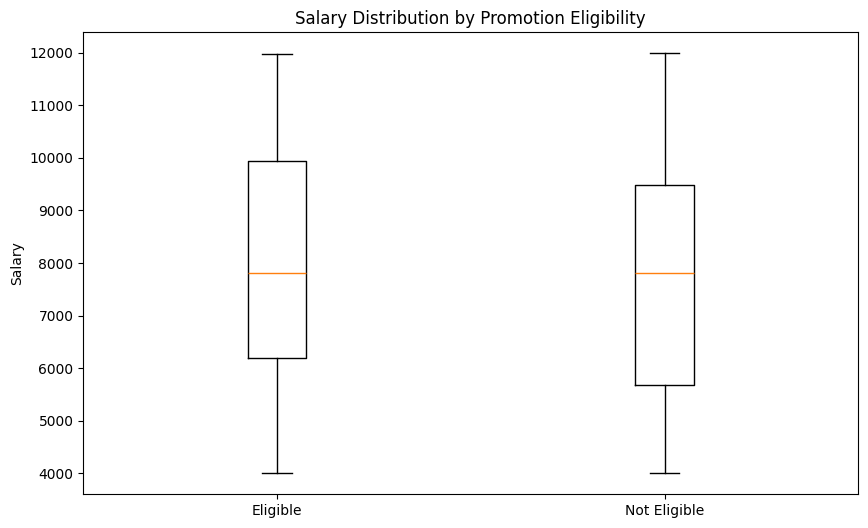

In [141]:
plt.figure(figsize=(10, 6))
plt.boxplot([eligible, non_eligible], labels=['Eligible', 'Not Eligible'])
plt.title('Salary Distribution by Promotion Eligibility')
plt.ylabel('Salary')
plt.show()

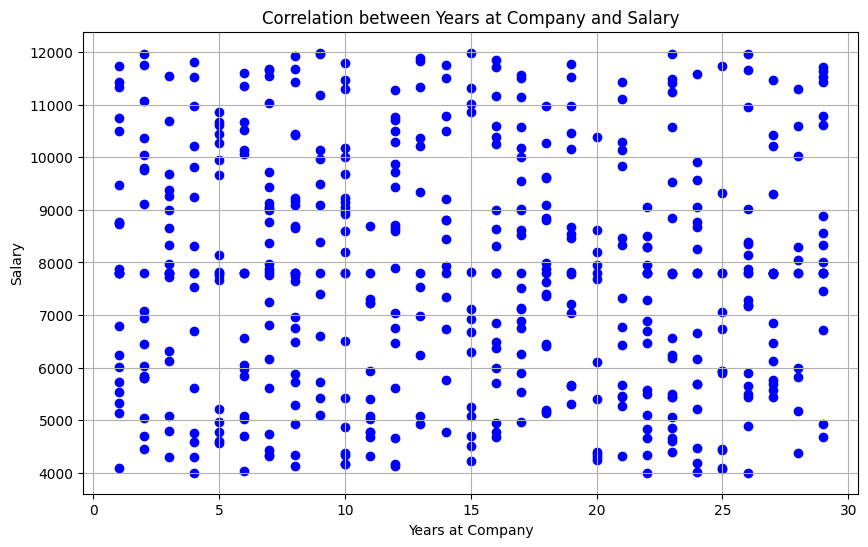

In [142]:
plt.figure(figsize=(10, 6))
plt.scatter(df['S_Duration'], df['Salary'], color='blue')
plt.title('Correlation between Years at Company and Salary')
plt.xlabel('Years at Company')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

ValueError: num must be an integer with 1 <= num <= 4, not 5

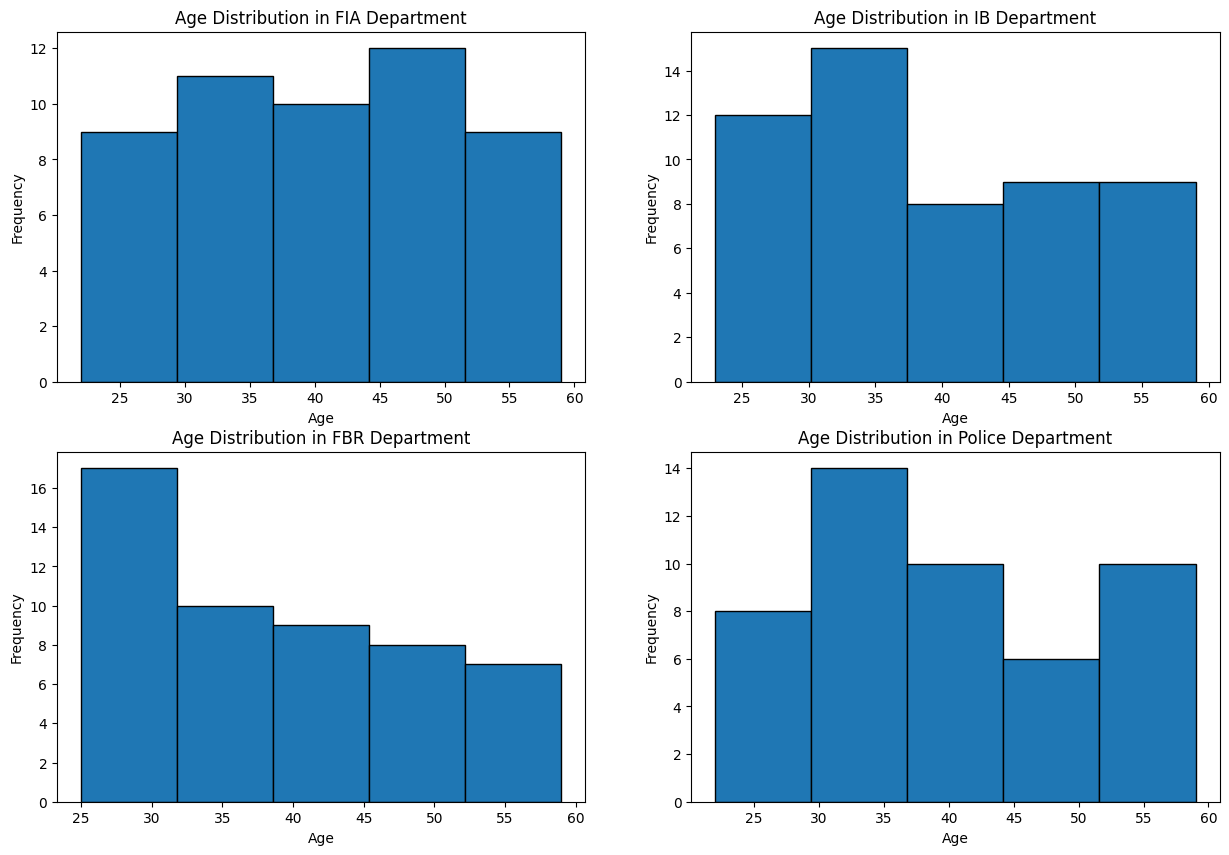

In [143]:
# Group by 'Department'
departments = df['Department'].unique()

# Create a histogram for each department
plt.figure(figsize=(15, 10))
for i, department in enumerate(departments, 1):
    plt.subplot(2, 2, i)
    df[df['Department'] == department]['Age'].plot(kind='hist', bins=5, edgecolor='black')
    plt.title(f'Age Distribution in {department} Department')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
